In [16]:
import numpy as np
import h5py
from pathlib import Path
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 4)
plt.rcParams['axes.grid'] = True


In [17]:
DATA_DIR = Path("C:/Users/ceti/Documents/01_projects/force-insertion-sim/obs")
EPISODE = "episode_0001/episode.h5"

with h5py.File(DATA_DIR / EPISODE, "r") as f:
    # Print structure
    for group in f.keys():
        if isinstance(f[group], h5py.Group):
            signals = list(f[group].keys())
            shapes = {k: f[group][k].shape for k in signals}
            print(f"{group}: {shapes}")

    # Load arrays
    ts       = f["obs/timestamps"][:]
    f_ext    = f["obs/f_ext"][:]
    f_int    = f["obs/f_internal"][:]
    ee_vel   = f["obs/ee_velocity"][:]
    Fff      = f["action/Fff"][:]
    meta     = {k: f["meta"][k][()] for k in f["meta"].keys()}

t = ts - ts[0]
print(f"\nEpisode: success={meta['success']}, duration={t[-1]:.2f}s, steps={len(t)}, ee_vel shape={ee_vel.shape}")

action: {'Fff': (6062, 6)}
debug: {'ee_pose': (6062, 7), 'mode': (6062,), 'peg_tip_pos': (6062, 3), 'q': (6062, 7)}
meta: {'duration': (), 'fail_phase': (), 'hole_pos': (3,), 'hole_quat': (4,), 'n_steps': (), 'success': ()}
obs: {'ee_velocity': (6062, 6), 'f_ext': (6062, 6), 'f_internal': (6062, 6), 'timestamps': (6062,)}

Episode: success=True, duration=30.30s, steps=6062, ee_vel shape=(6062, 6)


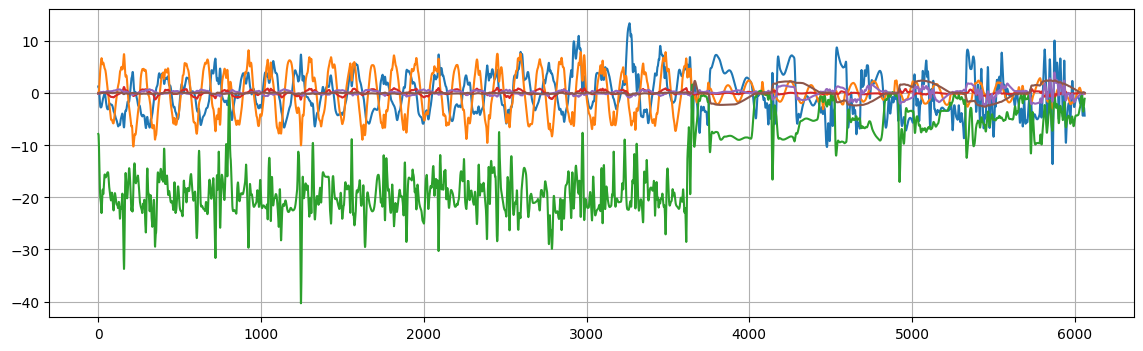

In [18]:
plt.plot(f_ext)
plt.show()

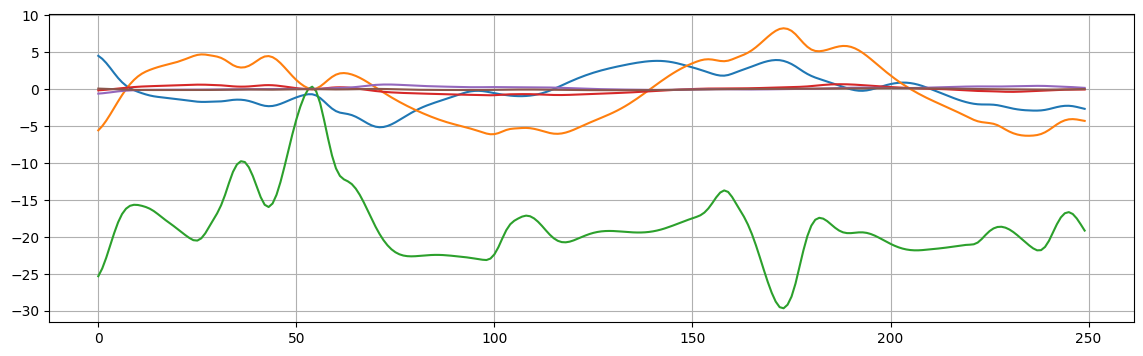

In [19]:
start, stop = 750, 1000
plt.plot(f_ext[start:stop,:])
plt.show()

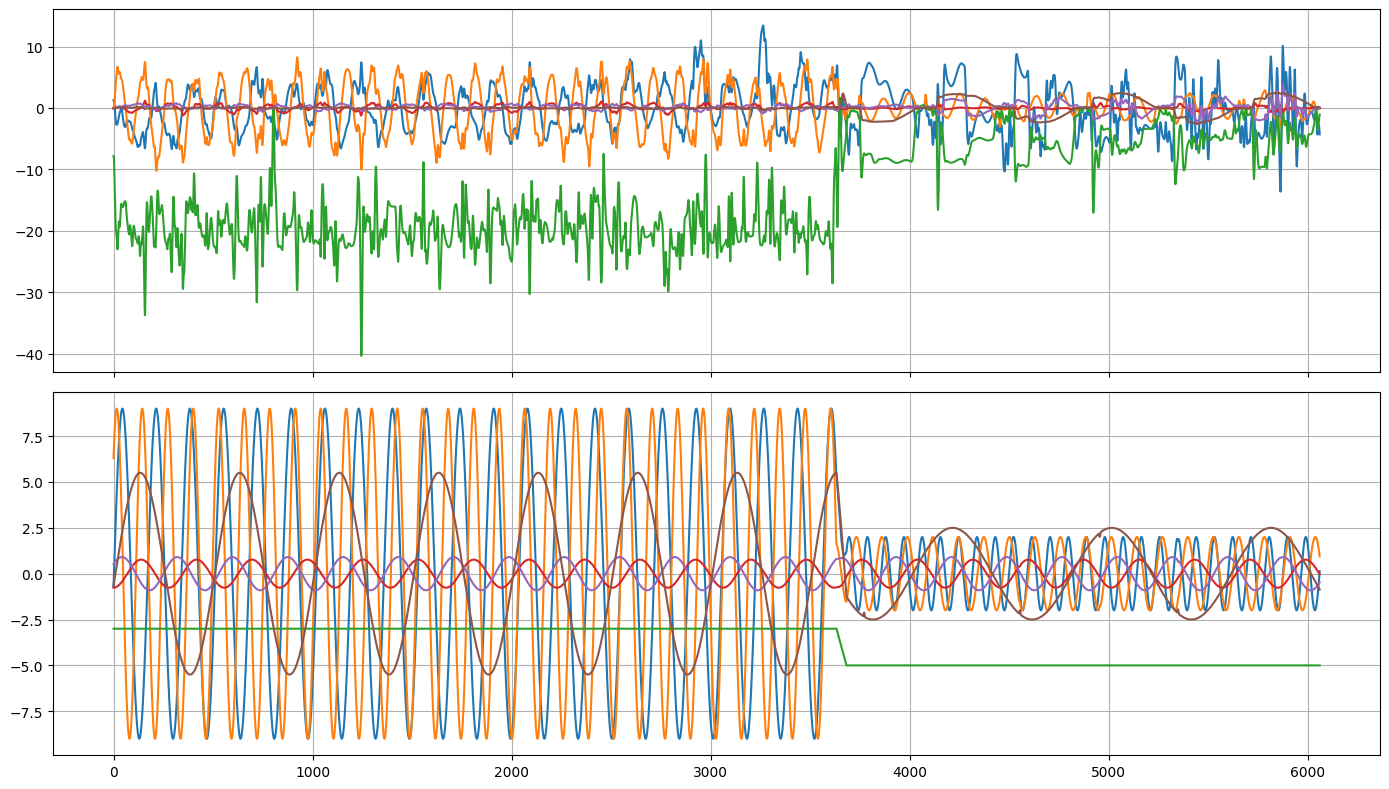

In [20]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(f_ext)

axes[1].plot(Fff)


plt.tight_layout()
plt.show()

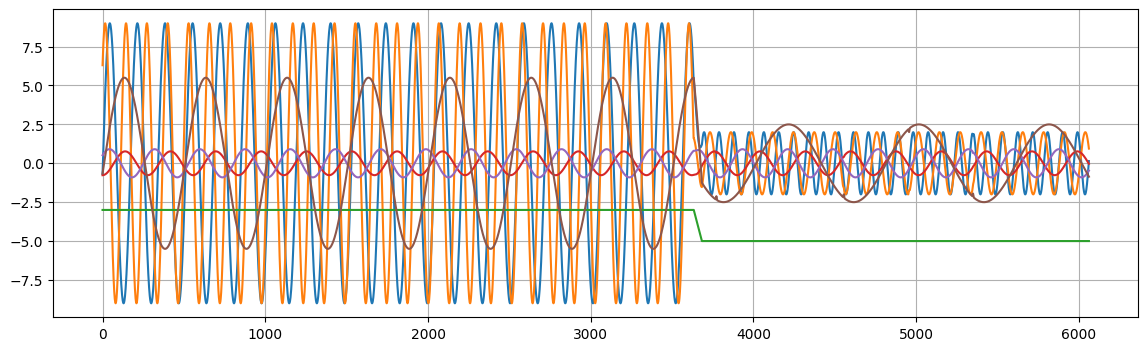

In [21]:
plt.plot(Fff)
plt.show()

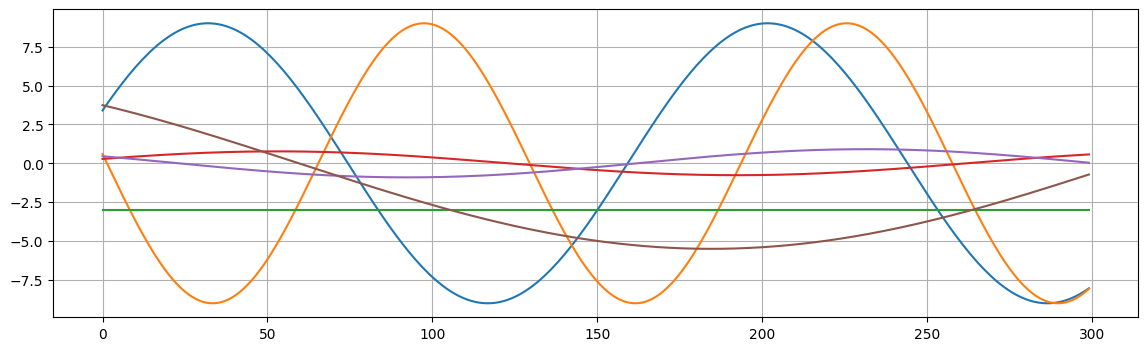

In [22]:
start, stop = 1200, 1500
plt.plot(Fff[start:stop,:])
plt.show()